In [1]:
import os
import sys
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression

project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
sys.path.insert(0, os.path.join(project_root,"src"))
sys.path.insert(0, project_root)

# from pydplan_profiletools import calculatePlan, DivePlan, TankType
import gf_selection

In [2]:
df = pd.DataFrame()
df['depth'] =  [d for d in range(12,40, 3)]
df['d_feet'] = round(df['depth']*gf_selection.FEET_IN_METER, -1).astype(int)   # TODO: Round always to the conservative direction
df['surface_time'] = 90
df['first_dive_time'] = df['d_feet'].apply(lambda x: gf_selection.btt[str(x)].max())
df['PADI_1st_dive'] = df['d_feet'].apply(lambda x: gf_selection.btt[gf_selection.btt['Pressure group']<='U'][str(x)].max())

# Determine of the maximum no decompression time for a second dive, based on the PADI dive table.
df['same_depth_second_dive'] = df.apply(lambda x: gf_selection.second_dive_no_dec_time(x['first_dive_time'], x['surface_time'], x['d_feet']), axis=1)

In [3]:
# If the first results in group U or better, and the surface time is at least 90 minutes, the outcome group will be E or better.
gf_selection.sfi[gf_selection.sfi['Next pressure group'] == 'E']

,Next pressure group,A,B,C,D,E,F,G,H,I,...,R,S,T,U,V,W,X,Y,Z,Unnamed: 27
21,E,NaN,NaN,NaN,NaN,7.0,15.0,22.0,28.0,34.0,...,75.0,78.0,82.0,85.0,88.0,91.0,94.0,97.0,100,NaN


In [4]:
second_dive_pressure_group = 'E'
df['PADI_2nd_dive'] = df['d_feet'].apply(lambda x: 
    gf_selection.btt[str(x)].max() # Original bottom time
    - gf_selection.rnt.loc[gf_selection.rnt['Depth (fsw)'] == x, second_dive_pressure_group].values[0] # Residual Nitrogen Time (RNT) in minutes 
) 

In [5]:
def first_dive_no_dec_time(depth, gf_high = 85):
    surface_time = 90
    for T in range(100, 1, -1):
        max_ceiling = gf_selection.get_max_ceiling([depth], [T], [gf_high], surface_time, plot_figure=False)
        if max_ceiling < 0:
            return T

In [6]:
df['GF_90_1st_dive'] = df['depth'].apply(lambda x: first_dive_no_dec_time(x, gf_high = 90))
df['GF_80_1st_dive'] = df['depth'].apply(lambda x: first_dive_no_dec_time(x, gf_high = 80))
df['GF_70_1st_dive'] = df['depth'].apply(lambda x: first_dive_no_dec_time(x, gf_high = 70))

In [7]:
df['table_0'] = df[['PADI_1st_dive', 'GF_90_1st_dive']].min(axis=1)

In [8]:
def second_dive_no_dec_time(df, depth, gf_high = 85):
    surface_time = 90
    for T in range(100, 1, -1):
        valid = True
        for first_dive_depth, first_dive_time in zip(df['depth'], df['table_0']):
            max_ceiling = gf_selection.get_max_ceiling(
                [first_dive_depth, depth],
                [first_dive_time, T],
                [125, gf_high],    # 125 high gradient for the first dive to make sure no ceiling there
                surface_time,
                plot_figure=False
            )
            if max_ceiling > 0:
                valid=False
                break
        if valid:
            return T

In [9]:
df['GF_90_2nd_dive'] = df['depth'].apply(lambda x: second_dive_no_dec_time(df, x, gf_high = 90))

In [10]:
df['table_1'] = df[['PADI_2nd_dive', 'GF_90_2nd_dive', 'GF_80_1st_dive']].min(axis=1)

In [11]:
df[['depth', 'table_0', 'table_1']]

,depth,table_0,table_1
0,12,97.0,100.0
1,15,67.0,59.0
2,18,48.0,38.0
3,21,32.0,25.0
4,24,23.0,17.0
5,27,16.0,13.0
6,30,13.0,9.0
7,33,10.0,7.0
8,36,8.0,4.0
9,39,6.0,2.0


In [12]:
df['GF_80_2nd_dive'] = df['depth'].apply(lambda x: second_dive_no_dec_time(df, x, gf_high = 80))
df['GF_70_2nd_dive'] = df['depth'].apply(lambda x: second_dive_no_dec_time(df, x, gf_high = 70))
df['GF_60_2nd_dive'] = df['depth'].apply(lambda x: second_dive_no_dec_time(df, x, gf_high = 60))

In [13]:
df['table_2'] = df[['GF_80_2nd_dive', 'GF_70_1st_dive']].min(axis=1)

In [14]:
df.index = df['depth']

In [15]:
df[['table_0', 'table_1', 'table_2']].astype(int)

,table_0,table_1,table_2
depth,,,
12,97,100,85
15,67,59,47
18,48,38,28
21,32,25,18
24,23,17,13
27,16,13,9
30,13,9,7
33,10,7,4
36,8,4,3


In [16]:
df['GF_75_1st_dive'] = df['depth'].apply(lambda x: first_dive_no_dec_time(x, gf_high = 75))

In [17]:
df['source_0'] = df[['PADI_1st_dive', 'GF_90_1st_dive']].idxmin(axis=1)
df['source_1'] = df[['PADI_2nd_dive', 'GF_90_2nd_dive', 'GF_80_1st_dive']].idxmin(axis=1)
df['source_2'] = df[['GF_80_2nd_dive', 'GF_70_1st_dive']].idxmin(axis=1)

In [18]:
df[['source_0', 'source_1', 'source_2']]

,source_0,source_1,source_2
depth,,,
12,PADI_1st_dive,GF_90_2nd_dive,GF_70_1st_dive
15,PADI_1st_dive,PADI_2nd_dive,GF_70_1st_dive
18,GF_90_1st_dive,PADI_2nd_dive,GF_70_1st_dive
21,GF_90_1st_dive,PADI_2nd_dive,GF_70_1st_dive
24,GF_90_1st_dive,PADI_2nd_dive,GF_70_1st_dive
27,GF_90_1st_dive,GF_90_2nd_dive,GF_80_2nd_dive
30,GF_90_1st_dive,GF_90_2nd_dive,GF_70_1st_dive
33,GF_90_1st_dive,PADI_2nd_dive,GF_80_2nd_dive
36,GF_90_1st_dive,GF_90_2nd_dive,GF_80_2nd_dive


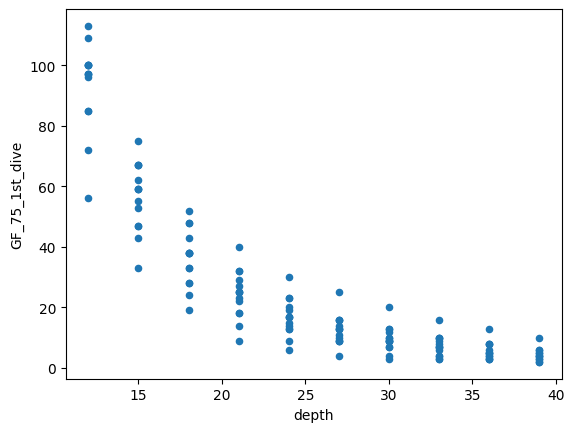

In [21]:
ax = None
for c in ['PADI_1st_dive',
       'same_depth_second_dive', 'PADI_2nd_dive', 'GF_90_1st_dive',
       'GF_80_1st_dive', 'GF_70_1st_dive', 'table_0', 'GF_90_2nd_dive',
       'table_1', 'GF_80_2nd_dive', 'GF_70_2nd_dive', 'GF_60_2nd_dive',
       'table_2', 'GF_75_1st_dive']:
    ax = df.plot.scatter(x='depth', y=c, ax=ax)

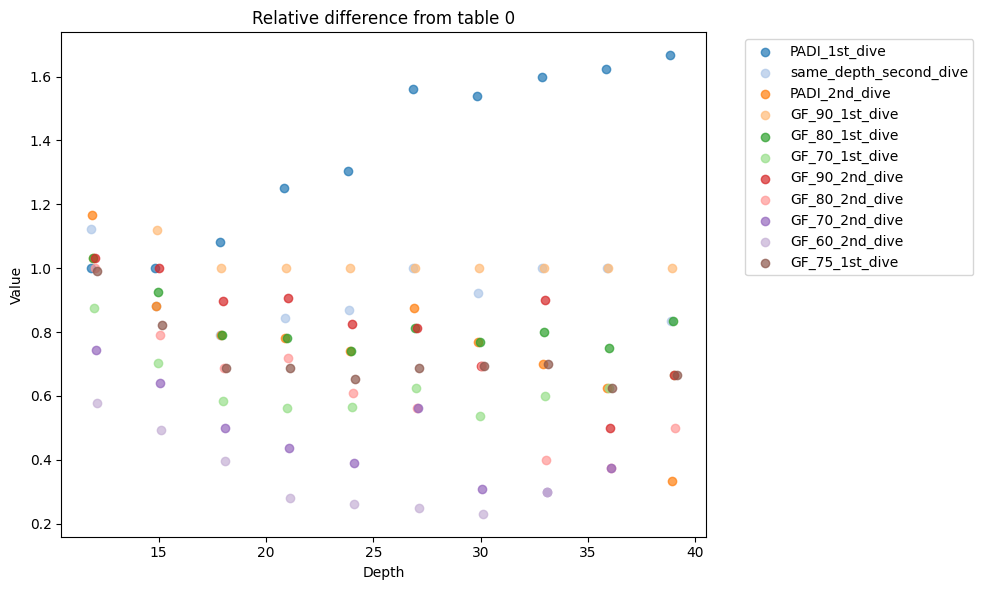

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab20.colors  # Use a colormap with many distinct colors

columns = ['PADI_1st_dive', 'same_depth_second_dive', 'PADI_2nd_dive', 'GF_90_1st_dive',
           'GF_80_1st_dive', 'GF_70_1st_dive', 'GF_90_2nd_dive',
           'GF_80_2nd_dive', 'GF_70_2nd_dive', 'GF_60_2nd_dive',
           'GF_75_1st_dive']

for i, col in enumerate(columns):
    jitter = (i - len(columns)/2) * 0.03  # Slight offset for each group
    ax.scatter(df['depth'] + jitter, df[col]/df['table_0'], label=col, color=colors[i % len(colors)], alpha=0.7)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title("Relative difference from table 0")
ax.set_xlabel("Depth")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()



In [26]:
df[['depth', 'GF_90_1st_dive', 'GF_90_2nd_dive']]

,depth,GF_90_1st_dive,GF_90_2nd_dive
depth,,,
12,12,100,100
15,15,75,67
18,18,48,43
21,21,32,29
24,24,23,19
27,27,16,13
30,30,13,9
33,33,10,9
36,36,8,4
